In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from darts import TimeSeries
from darts.models import RandomForestModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, rmse, mae, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
import shap

COLORS = {
    'IHSG': '#2E7D32', 'M2_YoY': '#1976D2', 'USDIDR': '#7B1FA2',
    'BI_Rate': '#F57C00', 'NPL_Ratio': '#C2185B',
    'train': '#2E7D32', 'actual': '#1976D2', 'predicted': '#D32F2F',
}

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


## Data Gathering and preprocessing

In [ ]:
url = 'https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/model1-new.csv'
df = pd.read_csv(url)

df_clean = df.copy()

df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d/%m/%Y') + pd.offsets.MonthEnd(0)

pct_columns = ['BI Interest Rate', 'npl_ratio']
for col in pct_columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].str.replace('%', '').astype(float)

df_clean = df_clean.sort_values('Date').reset_index(drop=True)
df_clean.columns = ['Date', 'IHSG', 'Inflation_YoY', 'M2_YoY', 'USDIDR',
                     'BI_Rate', 'NPL_Ratio', 'M2_MoM']

# Select 4 covariates (drop Inflation, konsisten dengan model klasifikasi)
TARGET_COL = 'IHSG'
COVARIATE_COLS = ['M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']

df_model = df_clean[['Date', TARGET_COL] + COVARIATE_COLS].copy()
df_model = df_model.dropna().reset_index(drop=True)

print(f"Date Range: {df_model['Date'].min()} to {df_model['Date'].max()}")
print(f"Total Months: {len(df_model)}")
print(f"Target: {TARGET_COL}")
print(f"Covariates: {COVARIATE_COLS}")
print(f"\nFirst 5 rows:")
print(df_model.head().to_string(index=False))

Date Range: 2015-01-31 00:00:00 to 2025-01-31 00:00:00
Total Months: 121
Target: IHSG
Covariates: ['M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']

First 5 rows:
      Date     IHSG  M2_YoY  USDIDR  BI_Rate  NPL_Ratio
2015-01-31 5289.404   14.31 12755.0     7.75       2.37
2015-02-28 5450.294   16.04 12928.0     7.50       2.43
2015-03-31 5518.675   16.26 13075.0     7.50       2.40
2015-04-30 5086.425   14.88 12964.0     7.50       2.48
2015-05-31 5216.379   13.42 13225.0     7.50       2.58


### Data Preprocessing


CELL 3: DESCRIPTIVE STATISTICS & EDA

--- Descriptive Statistics ---
            IHSG    M2_YoY      USDIDR   BI_Rate  NPL_Ratio
count   121.0000  121.0000    121.0000  121.0000   121.0000
mean   6077.3762    8.8132  14363.8017    5.2541     2.7684
std     850.6066    2.7388    895.7909    1.2370     0.3203
min    4223.9080    3.3500  12755.0000    3.5000     2.0800
25%    5386.6920    6.7700  13655.0000    4.2500     2.5200
50%    6056.1240    8.1800  14273.0000    5.2500     2.7600
75%    6843.2390   10.5300  14903.0000    6.0000     3.0500
max    7670.7330   16.2600  16375.0000    7.7500     3.3500

--- Correlation with IHSG ---
  M2_YoY         : -0.3763 (Moderate)
  USDIDR         : +0.6227 (Strong)
  BI_Rate        : -0.2353 (Weak)
  NPL_Ratio      : -0.4360 (Moderate)


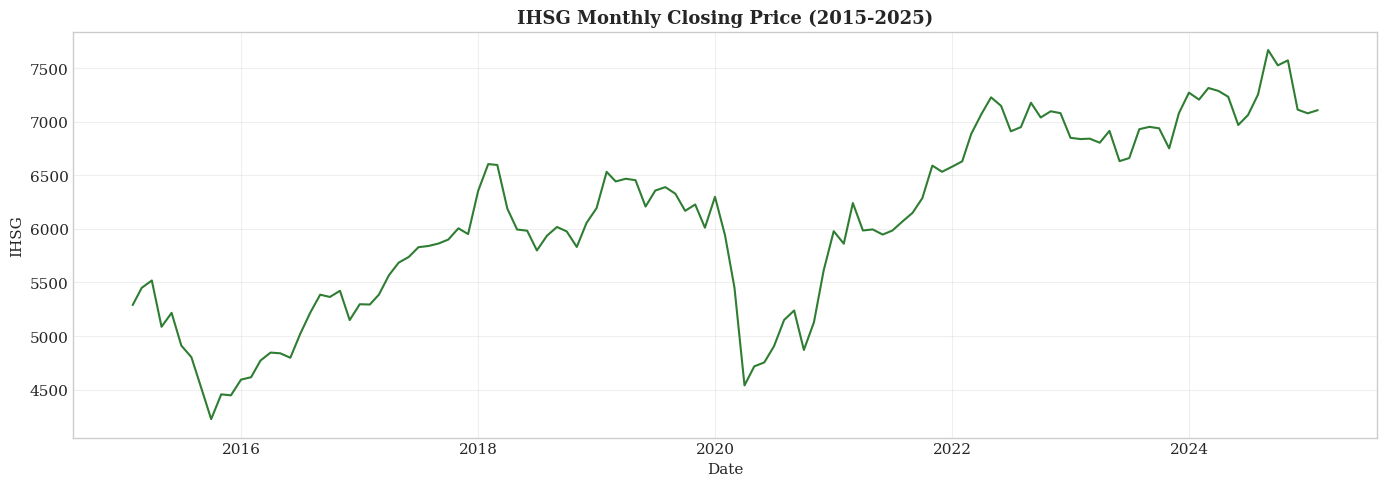

✅ Saved: regression_eda_ihsg.png


In [ ]:
print("\n" + "=" * 70)
print("CELL 3: DESCRIPTIVE STATISTICS & EDA")
print("=" * 70)

print("\n--- Descriptive Statistics ---")
print(df_model[['IHSG', 'M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']].describe().round(4).to_string())

print("\n--- Correlation with IHSG ---")
for col in COVARIATE_COLS:
    corr = df_model[col].corr(df_model['IHSG'])
    strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
    print(f"  {col:15s}: {corr:+.4f} ({strength})")

# Plot: IHSG time series
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_model['Date'], df_model['IHSG'], color=COLORS['IHSG'], linewidth=1.5)
ax.set_title('IHSG Monthly Closing Price (2015-2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('IHSG')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('regression_eda_ihsg.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: regression_eda_ihsg.png")

In [ ]:
print("\n" + "=" * 70)
print("CELL 4: DARTS TIMESERIES & TRAIN/TEST SPLIT")
print("=" * 70)

df_ts = df_model.set_index('Date')
df_ts = df_ts.asfreq('ME')

target_series = TimeSeries.from_dataframe(
    df_ts, value_cols=TARGET_COL, fill_missing_dates=True, freq='ME'
)
covar_series = TimeSeries.from_dataframe(
    df_ts, value_cols=COVARIATE_COLS, fill_missing_dates=True, freq='ME'
)

# Train/Test Split 80:20
split_point = int(len(target_series) * 0.8)
train_target = target_series[:split_point]
test_target = target_series[split_point:]
train_cov = covar_series[:split_point]
test_cov = covar_series[split_point:]


CELL 4: DARTS TIMESERIES & TRAIN/TEST SPLIT


In [ ]:
scaler_target = Scaler(scaler=MinMaxScaler())
scaler_cov = Scaler(scaler=MinMaxScaler())

# Fit scalers on TRAINING data only
train_target_scaled = scaler_target.fit_transform(train_target)
train_cov_scaled = scaler_cov.fit_transform(train_cov)

# Transform test & full using train-fitted scalers
test_target_scaled = scaler_target.transform(test_target)
test_cov_scaled = scaler_cov.transform(test_cov)
target_scaled = scaler_target.transform(target_series)
cov_scaled = train_cov_scaled.append(test_cov_scaled)

print(f"Train: {train_target.start_time()} → {train_target.end_time()} ({len(train_target)} obs)")
print(f"Test:  {test_target.start_time()} → {test_target.end_time()} ({len(test_target)} obs)")
print(f"\n✓ Scalers fit on TRAINING data only")
print(f"✓ Target scaled: MinMaxScaler [0, 1]")
print(f"✓ Covariates scaled: MinMaxScaler [0, 1]")

# Verify no leakage
print(f"\n--- Data Leakage Check ---")
print(f"  scaler_target fit range: {train_target.start_time()} → {train_target.end_time()}")
print(f"  scaler_cov fit range:    {train_cov.start_time()} → {train_cov.end_time()}")
print(f"  ✓ No data leakage")

Train: 2015-01-31 00:00:00 → 2022-12-31 00:00:00 (96 obs)
Test:  2023-01-31 00:00:00 → 2025-01-31 00:00:00 (25 obs)

✓ Scalers fit on TRAINING data only
✓ Target scaled: MinMaxScaler [0, 1]
✓ Covariates scaled: MinMaxScaler [0, 1]

--- Data Leakage Check ---
  scaler_target fit range: 2015-01-31 00:00:00 → 2022-12-31 00:00:00
  scaler_cov fit range:    2015-01-31 00:00:00 → 2022-12-31 00:00:00
  ✓ No data leakage


In [ ]:
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

OUTPUT_CHUNK_LENGTH = 1

def objective(trial):
    lags = trial.suggest_categorical('lags', [1, 3, 6, 12])
    lags_past_covariates = trial.suggest_categorical('lags_past_covariates', [1, 3, 6, 12])
    n_estimators = trial.suggest_categorical('n_estimators', [50, 100, 200])
    max_depth = trial.suggest_categorical('max_depth', [3, 5, 7, None])
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    min_samples_split = trial.suggest_categorical('min_samples_split', [2, 5, 10])
    min_samples_leaf = trial.suggest_categorical('min_samples_leaf', [1, 2, 4])
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    criterion = trial.suggest_categorical('criterion', ['squared_error', 'friedman_mse'])

    try:
        model = RandomForestModel(
            lags=lags,
            lags_past_covariates=lags_past_covariates,
            output_chunk_length=OUTPUT_CHUNK_LENGTH,
            n_estimators=n_estimators,
            max_depth=max_depth,
            multi_models=True,
            random_state=42,
            max_features=max_features,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            criterion=criterion,
            n_jobs=-1,
        )
        # FIT ON TRAIN ONLY with TRAIN covariates
        model.fit(train_target_scaled, past_covariates=cov_scaled)

        # Evaluate via historical_forecasts (1-step-ahead)
        backtest_pred = model.historical_forecasts(
            series=target_scaled,
            past_covariates=cov_scaled,
            start=test_target_scaled.start_time(),
            forecast_horizon=1,
            stride=1,
            retrain=False,
            verbose=False,
        )

        mape_score = mape(test_target_scaled, backtest_pred)
        return mape_score

    except Exception as e:
        return float('inf')

In [ ]:
def print_callback(study, trial):
    if trial.number % 10 == 0:
        print(f"  Trial {trial.number}: MAPE = {trial.value:.4f}% | Best: {study.best_value:.4f}%")

N_TRIALS = 100

In [ ]:
# Print search space
total_combinations = 4 * 4 * 3 * 4 * 3 * 3 * 3 * 2 * 2
print(f"Search Space:")
print(f"  lags: [1, 3, 6, 12]")
print(f"  lags_past_covariates: [1, 3, 6, 12]")
print(f"  n_estimators: [50, 100, 200]")
print(f"  max_depth: [3, 5, 7, None]")
print(f"  max_features: ['sqrt', 'log2', None]")
print(f"  min_samples_split: [2, 5, 10]")
print(f"  min_samples_leaf: [1, 2, 4]")
print(f"  bootstrap: [True, False]")
print(f"  criterion: ['squared_error', 'friedman_mse']")
print(f"\nTotal possible combinations: {total_combinations:,}")
print(f"Trials: {N_TRIALS} ({N_TRIALS/total_combinations*100:.1f}% of search space)")
print(f"Forecast horizon: {OUTPUT_CHUNK_LENGTH} month (1-step-ahead)")
print(f"\nRunning Optuna TPE...")

study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    callbacks=[print_callback],
    show_progress_bar=True,
)

best_params = study.best_trial.params.copy()
best_params['output_chunk_length'] = OUTPUT_CHUNK_LENGTH
best_score = study.best_value

print(f"\n{'=' * 60}")
print(f"OPTUNA RESULTS")
print(f"{'=' * 60}")
print(f"Best MAPE: {best_score:.4f}%")
print(f"\nBest Hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

# Save best params
with open('rf_regression_best_params.json', 'w') as f:
    json.dump({k: str(v) if v is None else v for k, v in best_params.items()}, f, indent=2)
print("✓ Saved: rf_regression_best_params.json")

Search Space:
  lags: [1, 3, 6, 12]
  lags_past_covariates: [1, 3, 6, 12]
  n_estimators: [50, 100, 200]
  max_depth: [3, 5, 7, None]
  max_features: ['sqrt', 'log2', None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  bootstrap: [True, False]
  criterion: ['squared_error', 'friedman_mse']

Total possible combinations: 20,736
Trials: 100 (0.5% of search space)
Forecast horizon: 1 month (1-step-ahead)

Running Optuna TPE...


  0%|          | 0/100 [00:00<?, ?it/s]

  Trial 0: MAPE = 23.9947% | Best: 23.9947%
  Trial 10: MAPE = 11.3521% | Best: 7.1226%
  Trial 20: MAPE = 26.4675% | Best: 5.9420%
  Trial 30: MAPE = 20.7018% | Best: 5.9420%
  Trial 40: MAPE = 9.9278% | Best: 5.9420%
  Trial 50: MAPE = 7.6056% | Best: 5.9420%
  Trial 60: MAPE = 5.9420% | Best: 5.9420%
  Trial 70: MAPE = 7.2974% | Best: 5.9420%
  Trial 80: MAPE = 5.9420% | Best: 5.9420%
  Trial 90: MAPE = 7.6056% | Best: 5.9420%

OPTUNA RESULTS
Best MAPE: 5.9420%

Best Hyperparameters:
  lags: 12
  lags_past_covariates: 1
  n_estimators: 100
  max_depth: 3
  max_features: None
  min_samples_split: 10
  min_samples_leaf: 4
  bootstrap: False
  criterion: friedman_mse
  output_chunk_length: 1
✓ Saved: rf_regression_best_params.json


In [ ]:
print("\n" + "=" * 70)
print("CELL 6: FINAL MODEL & PREDICTIONS")
print("=" * 70)

# Build final model with best params
final_model = RandomForestModel(
    lags=best_params['lags'],
    lags_past_covariates=best_params['lags_past_covariates'],
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    multi_models=True,
    random_state=42,
    max_features=best_params.get('max_features'),
    min_samples_split=best_params.get('min_samples_split', 2),
    min_samples_leaf=best_params.get('min_samples_leaf', 1),
    bootstrap=best_params.get('bootstrap', True),
    criterion=best_params.get('criterion', 'squared_error'),
    n_jobs=-1,
)

# Fit on training data
final_model.fit(train_target_scaled, past_covariates=cov_scaled)
print("✓ Final model fitted on training data")

# Generate predictions via historical_forecasts (1-step-ahead)
predictions_scaled = final_model.historical_forecasts(
    series=target_scaled,
    past_covariates=cov_scaled,
    start=test_target_scaled.start_time(),
    forecast_horizon=1,
    stride=1,
    retrain=False,
    verbose=True,
)

# Inverse transform to original scale
predictions = scaler_target.inverse_transform(predictions_scaled)
test_actual = scaler_target.inverse_transform(test_target_scaled)

print(f"\nPredictions: {len(predictions)} time steps")
print(f"Period: {predictions.start_time()} → {predictions.end_time()}")




CELL 6: FINAL MODEL & PREDICTIONS
✓ Final model fitted on training data


historical forecasts:   0%|          | 0/1 [00:00<?, ?it/s]


Predictions: 25 time steps
Period: 2023-01-31 00:00:00 → 2025-01-31 00:00:00


In [ ]:
# =====================================================
# CELL 7: MODEL EVALUATION
# =====================================================
print("\n" + "=" * 70)
print("CELL 7: MODEL EVALUATION")
print("=" * 70)

mape_score = mape(test_actual, predictions)
rmse_score = rmse(test_actual, predictions)
mae_score = mae(test_actual, predictions)
r2 = r2_score(test_actual, predictions)

# Directional accuracy
actual_vals = test_actual.values().flatten()
pred_vals = predictions.values().flatten()
min_len = min(len(actual_vals), len(pred_vals))
actual_vals = actual_vals[:min_len]
pred_vals = pred_vals[:min_len]

# Direction: compare with previous actual value
actual_direction = np.diff(actual_vals) > 0
pred_direction = (pred_vals[1:] - actual_vals[:-1]) > 0
directional_accuracy = np.mean(actual_direction == pred_direction)

print(f"\n{'─' * 50}")
print("Random Forest Regression — Performance Metrics")
print(f"{'─' * 50}")
print(f"  MAPE  : {mape_score:.4f}%")
print(f"  RMSE  : {rmse_score:.4f}")
print(f"  MAE   : {mae_score:.4f}")
print(f"  R²    : {r2:.4f}")
print(f"  Directional Accuracy: {directional_accuracy:.4f} ({directional_accuracy*100:.1f}%)")

metrics_dict = {
    'MAPE': mape_score,
    'RMSE': rmse_score,
    'MAE': mae_score,
    'R2': r2,
    'Directional_Accuracy': directional_accuracy,
}

# Residual analysis
residuals = actual_vals - pred_vals
print(f"\n{'─' * 50}")
print("Residual Analysis")
print(f"{'─' * 50}")
print(f"  Mean Residual     : {residuals.mean():.4f}")
print(f"  Std Residual      : {residuals.std():.4f}")
print(f"  Max Overestimate  : {residuals.min():.4f}")
print(f"  Max Underestimate : {residuals.max():.4f}")




CELL 7: MODEL EVALUATION

──────────────────────────────────────────────────
Random Forest Regression — Performance Metrics
──────────────────────────────────────────────────
  MAPE  : 2.4405%
  RMSE  : 234.0988
  MAE   : 175.9429
  R²    : 0.2266
  Directional Accuracy: 0.6667 (66.7%)

──────────────────────────────────────────────────
Residual Analysis
──────────────────────────────────────────────────
  Mean Residual     : 75.1776
  Std Residual      : 221.6993
  Max Overestimate  : -315.2485
  Max Underestimate : 603.2735



CELL 8: VISUALIZATIONS


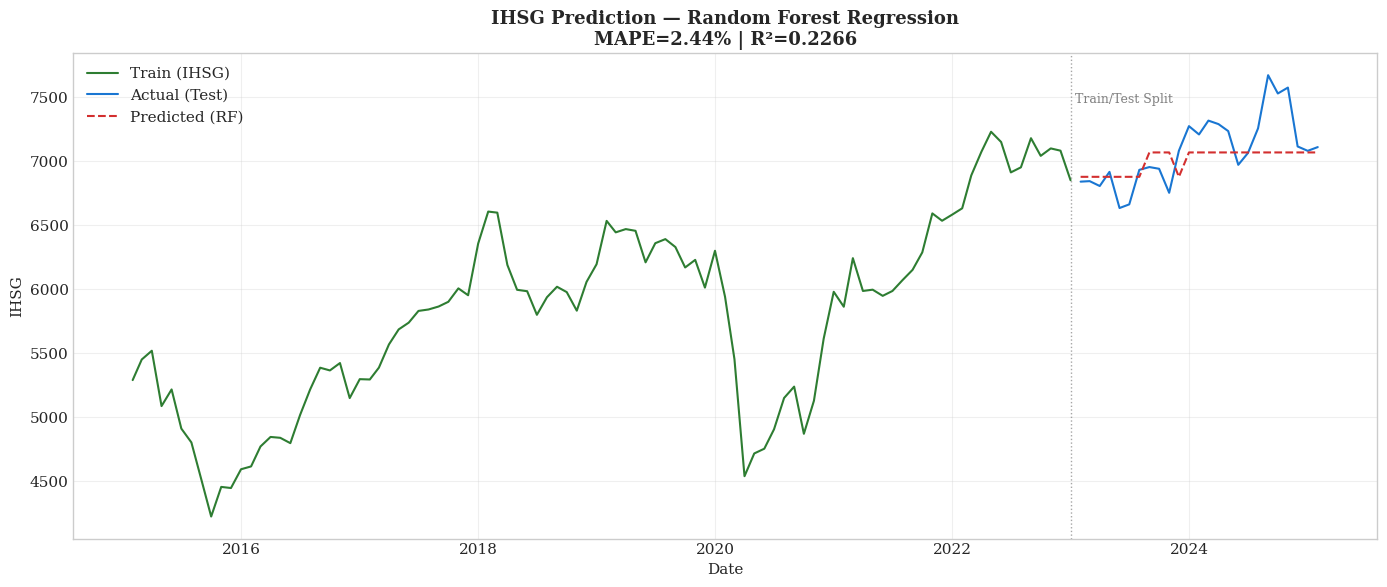

✅ Saved: regression_actual_vs_predicted.png


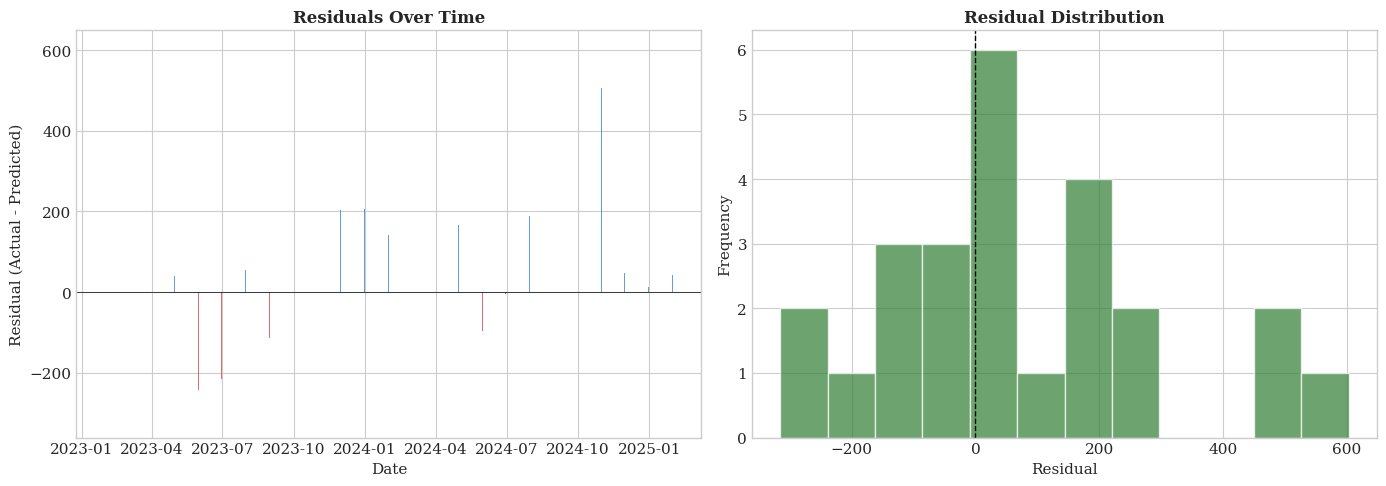

✅ Saved: regression_residuals.png


In [ ]:
print("\n" + "=" * 70)
print("CELL 8: VISUALIZATIONS")
print("=" * 70)

# Plot 1: Actual vs Predicted
fig, ax = plt.subplots(figsize=(14, 6))

full_actual = target_series.values().flatten()
full_dates = target_series.time_index

# Train period
ax.plot(full_dates[:split_point], full_actual[:split_point],
        color=COLORS['train'], linewidth=1.5, label='Train (IHSG)')

# Test actual
test_dates = test_actual.time_index
ax.plot(test_dates[:min_len], actual_vals,
        color=COLORS['actual'], linewidth=1.5, label='Actual (Test)')

# Predictions
pred_dates = predictions.time_index[:min_len]
ax.plot(pred_dates, pred_vals,
        color=COLORS['predicted'], linewidth=1.5, linestyle='--', label='Predicted (RF)')

# Split line
ax.axvline(x=train_target.end_time(), color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(train_target.end_time(), ax.get_ylim()[1] * 0.95, ' Train/Test Split',
        fontsize=9, color='gray')

ax.set_title(f'IHSG Prediction — Random Forest Regression\n'
             f'MAPE={mape_score:.2f}% | R²={r2:.4f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('IHSG')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regression_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: regression_actual_vs_predicted.png")

# Plot 2: Residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(pred_dates, residuals, color=[COLORS['actual'] if r > 0 else COLORS['predicted'] for r in residuals], alpha=0.7)
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_title('Residuals Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual (Actual - Predicted)')

axes[1].hist(residuals, bins=12, color=COLORS['IHSG'], alpha=0.7, edgecolor='white')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('regression_residuals.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: regression_residuals.png")


CELL 9: SHAP ANALYSIS
Features (16): ['IHSG_lag-1', 'IHSG_lag-2', 'IHSG_lag-3', 'IHSG_lag-4', 'IHSG_lag-5', 'IHSG_lag-6', 'IHSG_lag-7', 'IHSG_lag-8', 'IHSG_lag-9', 'IHSG_lag-10', 'IHSG_lag-11', 'IHSG_lag-12', 'M2_YoY_lag-1', 'USDIDR_lag-1', 'BI_Rate_lag-1', 'NPL_Ratio_lag-1']
X_train: (84, 16), X_test: (25, 16)

Standalone RF MAPE: 5.9420%
Darts RF MAPE:     2.4405%

Computing SHAP values...
SHAP values shape: (25, 16)

───────────────────────────────────────────────────────
Feature Importance — Mean |SHAP Value|
───────────────────────────────────────────────────────
  IHSG_lag-1                    : 0.372544 (93.8%)
  NPL_Ratio_lag-1               : 0.022772 (5.7%)
  IHSG_lag-6                    : 0.001741 (0.4%)
  IHSG_lag-3                    : 0.000000 (0.0%)
  IHSG_lag-4                    : 0.000000 (0.0%)
  IHSG_lag-5                    : 0.000000 (0.0%)
  IHSG_lag-7                    : 0.000000 (0.0%)
  IHSG_lag-2                    : 0.000000 (0.0%)
  IHSG_lag-8           

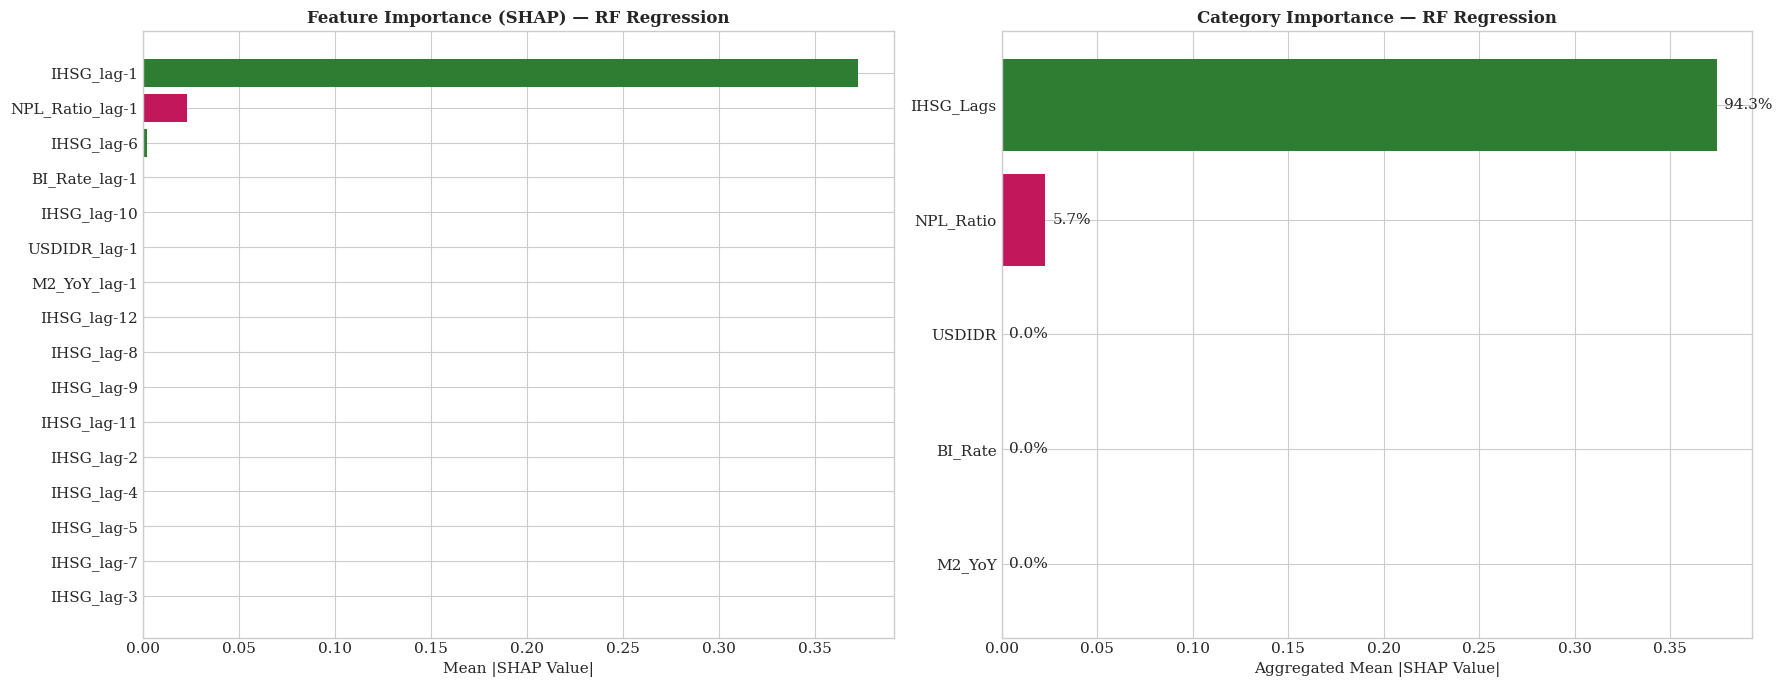

✅ Saved: regression_shap_importance.png


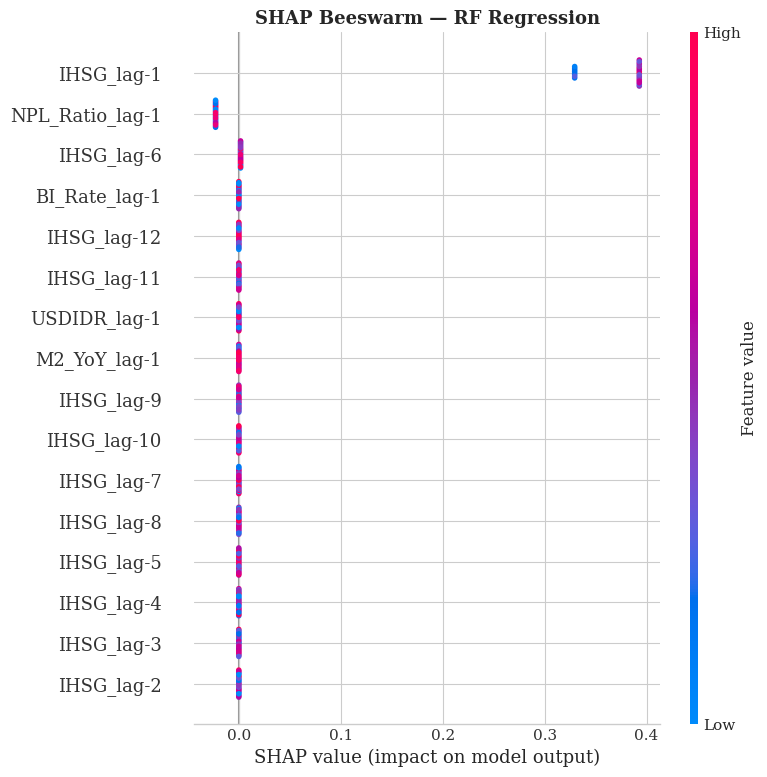

✅ Saved: regression_shap_beeswarm.png
✅ Saved: regression_shap_features.csv, regression_shap_categories.csv


In [ ]:
print("\n" + "=" * 70)
print("CELL 9: SHAP ANALYSIS")
print("=" * 70)

try:
    lags = best_params['lags']
    lags_cov = best_params['lags_past_covariates']

    target_full = target_scaled.values().flatten()
    covar_full_vals = cov_scaled.values()
    covar_names = COVARIATE_COLS

    # Build feature names
    feature_names = []
    for lag in range(1, lags + 1):
        feature_names.append(f'IHSG_lag-{lag}')
    for cov_name in covar_names:
        for lag in range(1, lags_cov + 1):
            feature_names.append(f'{cov_name}_lag-{lag}')

    start_idx = max(lags, lags_cov)

    # Build feature matrix
    X_all, y_all = [], []
    for t in range(start_idx, len(target_full)):
        row = []
        for lag in range(1, lags + 1):
            row.append(target_full[t - lag])
        for c in range(covar_full_vals.shape[1]):
            for lag in range(1, lags_cov + 1):
                row.append(covar_full_vals[t - lag, c])
        X_all.append(row)
        y_all.append(target_full[t])

    X_all = np.array(X_all)
    y_all = np.array(y_all)

    split_feat = split_point - start_idx
    X_train_shap = X_all[:split_feat]
    X_test_shap = X_all[split_feat:]
    y_train_shap = y_all[:split_feat]
    y_test_shap = y_all[split_feat:]

    print(f"Features ({len(feature_names)}): {feature_names}")
    print(f"X_train: {X_train_shap.shape}, X_test: {X_test_shap.shape}")

    # Train standalone RF with identical params
    rf_standalone = RandomForestRegressor(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        max_features=best_params.get('max_features'),
        min_samples_split=best_params.get('min_samples_split', 2),
        min_samples_leaf=best_params.get('min_samples_leaf', 1),
        bootstrap=best_params.get('bootstrap', True),
        criterion=best_params.get('criterion', 'squared_error'),
        random_state=42, n_jobs=-1,
    )
    rf_standalone.fit(X_train_shap, y_train_shap)

    # Validate
    from sklearn.metrics import mean_absolute_percentage_error
    standalone_preds = rf_standalone.predict(X_test_shap)
    standalone_mape = mean_absolute_percentage_error(y_test_shap, standalone_preds) * 100
    print(f"\nStandalone RF MAPE: {standalone_mape:.4f}%")
    print(f"Darts RF MAPE:     {mape_score:.4f}%")

    # SHAP
    print("\nComputing SHAP values...")
    explainer = shap.TreeExplainer(rf_standalone)
    shap_values = explainer.shap_values(X_test_shap)

    print(f"SHAP values shape: {shap_values.shape}")

    # Feature importance
    mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
    shap_df = pd.DataFrame({
        'Feature': feature_names,
        'Mean_Abs_SHAP': mean_abs_shap
    }).sort_values('Mean_Abs_SHAP', ascending=False)

    total_imp = shap_df['Mean_Abs_SHAP'].sum()
    print(f"\n{'─' * 55}")
    print("Feature Importance — Mean |SHAP Value|")
    print(f"{'─' * 55}")
    for _, row in shap_df.iterrows():
        pct = row['Mean_Abs_SHAP'] / total_imp * 100
        print(f"  {row['Feature']:30s}: {row['Mean_Abs_SHAP']:.6f} ({pct:.1f}%)")

    # Category aggregation
    def get_category(feat):
        if 'IHSG' in feat: return 'IHSG_Lags'
        elif 'M2_YoY' in feat: return 'M2_YoY'
        elif 'USDIDR' in feat: return 'USDIDR'
        elif 'BI_Rate' in feat: return 'BI_Rate'
        elif 'NPL' in feat: return 'NPL_Ratio'
        return 'Other'

    shap_df['Category'] = shap_df['Feature'].apply(get_category)
    cat_importance = shap_df.groupby('Category')['Mean_Abs_SHAP'].sum().sort_values(ascending=False)
    total_cat = cat_importance.sum()

    print(f"\n{'─' * 55}")
    print("Category Importance (Aggregated)")
    print(f"{'─' * 55}")
    for cat, imp in cat_importance.items():
        n_f = len(shap_df[shap_df['Category'] == cat])
        print(f"  {cat:25s}: {imp:.6f} ({imp/total_cat*100:.1f}%) [{n_f} feature(s)]")

    # SHAP Plots
    cat_colors = {
        'IHSG_Lags': COLORS['IHSG'], 'M2_YoY': COLORS['M2_YoY'],
        'USDIDR': COLORS['USDIDR'], 'BI_Rate': COLORS['BI_Rate'],
        'NPL_Ratio': COLORS['NPL_Ratio'], 'Other': '#666666',
    }

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sp = shap_df.sort_values('Mean_Abs_SHAP', ascending=True)
    bar_c = [cat_colors.get(get_category(f), '#666') for f in sp['Feature']]
    axes[0].barh(sp['Feature'], sp['Mean_Abs_SHAP'], color=bar_c)
    axes[0].set_title('Feature Importance (SHAP) — RF Regression', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Mean |SHAP Value|')

    cp = cat_importance.sort_values(ascending=True)
    cc = [cat_colors.get(c, '#666') for c in cp.index]
    axes[1].barh(cp.index, cp.values, color=cc)
    for i, (cat, val) in enumerate(cp.items()):
        axes[1].text(val + total_cat * 0.01, i, f'{val/total_cat*100:.1f}%', va='center', fontsize=11)
    axes[1].set_title('Category Importance — RF Regression', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Aggregated Mean |SHAP Value|')

    plt.tight_layout()
    plt.savefig('regression_shap_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: regression_shap_importance.png")

    fig, ax = plt.subplots(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test_shap, feature_names=feature_names, show=False)
    plt.title('SHAP Beeswarm — RF Regression', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('regression_shap_beeswarm.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: regression_shap_beeswarm.png")

    shap_df.to_csv('regression_shap_features.csv', index=False)
    cat_importance.to_csv('regression_shap_categories.csv')
    print("✅ Saved: regression_shap_features.csv, regression_shap_categories.csv")

except Exception as e:
    print(f"⚠️ SHAP analysis error: {e}")
    import traceback
    traceback.print_exc()

In [ ]:
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(f"""
{'=' * 60}
MODEL 1 REGRESI: PREDIKSI IHSG LEVEL (BULANAN)
{'=' * 60}

📊 DATA
   Periode        : {df_model['Date'].min().strftime('%B %Y')} — {df_model['Date'].max().strftime('%B %Y')}
   Observasi      : {len(df_model)} bulan
   Train/Test     : {len(train_target)}/{len(test_target)} ({len(train_target)/len(df_model)*100:.0f}%/{len(test_target)/len(df_model)*100:.0f}%)
   Target         : IHSG Level (closing price)

📈 COVARIATES (4 variabel, drop Inflation)
   1. M2_YoY      — Money Supply Growth YoY
   2. USDIDR      — USD/IDR Exchange Rate
   3. BI_Rate     — BI Interest Rate
   4. NPL_Ratio   — Non-Performing Loan Ratio

⚙️ METHODOLOGY
   Framework      : Darts (RandomForestModel)
   Tuning         : Optuna TPE ({N_TRIALS} trials)
   Forecast       : 1-step-ahead via historical_forecasts()
   Scaling        : MinMaxScaler [0,1] (fit on train only)
   SHAP           : TreeExplainer

🤖 RANDOM FOREST REGRESSOR
   MAPE           : {mape_score:.4f}%
   RMSE           : {rmse_score:.4f}
   MAE            : {mae_score:.4f}
   R²             : {r2:.4f}
   Dir. Accuracy  : {directional_accuracy:.4f} ({directional_accuracy*100:.1f}%)

⚙️ BEST HYPERPARAMETERS:
   {chr(10).join(f'   {k}: {v}' for k, v in best_params.items())}

📁 OUTPUT FILES
   regression_eda_ihsg.png
   regression_actual_vs_predicted.png
   regression_residuals.png
   regression_shap_importance.png
   regression_shap_beeswarm.png
   regression_shap_features.csv
   regression_shap_categories.csv
   rf_regression_best_params.json
""")

print(f"{'=' * 60}")
print("COMPLETE!")
print(f"{'=' * 60}")


FINAL SUMMARY

MODEL 1 REGRESI: PREDIKSI IHSG LEVEL (BULANAN)

📊 DATA
   Periode        : January 2015 — January 2025
   Observasi      : 121 bulan
   Train/Test     : 96/25 (79%/21%)
   Target         : IHSG Level (closing price)

📈 COVARIATES (4 variabel, drop Inflation)
   1. M2_YoY      — Money Supply Growth YoY
   2. USDIDR      — USD/IDR Exchange Rate
   3. BI_Rate     — BI Interest Rate
   4. NPL_Ratio   — Non-Performing Loan Ratio

⚙️ METHODOLOGY
   Framework      : Darts (RandomForestModel)
   Tuning         : Optuna TPE (100 trials)
   Forecast       : 1-step-ahead via historical_forecasts()
   Scaling        : MinMaxScaler [0,1] (fit on train only)
   SHAP           : TreeExplainer

🤖 RANDOM FOREST REGRESSOR
   MAPE           : 2.4405%
   RMSE           : 234.0988
   MAE            : 175.9429
   R²             : 0.2266
   Dir. Accuracy  : 0.6667 (66.7%)

⚙️ BEST HYPERPARAMETERS:
      lags: 12
   lags_past_covariates: 1
   n_estimators: 100
   max_depth: 3
   max_features: 

In [ ]:
pred_df = pd.DataFrame({
    'Date': predictions.time_index[:min_len],
    'Actual': actual_vals,
    'Predicted': pred_vals,
    'Error': residuals,
    'Error_%': (residuals / actual_vals) * 100,
})